# 02 - Features and piece-square tables

The evaluation function is a linear model:

$$\mathrm{score}(\text{position}) = \mathbf{w}^\top \boldsymbol{\phi}(\text{position})$$

Here $\boldsymbol{\phi}: \mathrm{Position} \to \mathbb{R}^{391}$ is the feature vector and $\mathbf{w} \in \mathbb{R}^{391}$ are the weights, in centipawns from white's POV.

This notebook looks at $\boldsymbol{\phi}$ and at the hand-crafted PeSTO piece-square tables we ship as a baseline. Notebook 04 will then learn $\mathbf{w}$ from data.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import chess
import chess.svg
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, display

from chess_engine.evaluate import Evaluator
from chess_engine.features import (
    BISHOP_PAIR_INDEX, FEATURE_NAMES, MATERIAL_SLICE,
    N_FEATURES, PSQT_SLICES, SIDE_TO_MOVE_INDEX, phi,
)
from chess_engine.psqt import MATERIAL, PSQT

## Feature layout

The 391-dim feature vector is laid out as:

| index range | what                                               | length |
|------------:|:---------------------------------------------------|-------:|
| `[0:5]`     | material counts $w-b$ for $\{P,N,B,R,Q\}$         | 5      |
| `[5:69]`    | pawn PSQT indicator: $\mathbf{1}_w - \mathbf{1}_{\bar b}$ | 64 |
| `[69:133]`  | knight PSQT                                        | 64     |
| `[133:197]` | bishop PSQT                                        | 64     |
| `[197:261]` | rook PSQT                                          | 64     |
| `[261:325]` | queen PSQT                                         | 64     |
| `[325:389]` | king PSQT                                          | 64     |
| `[389]`     | bishop pair (signed)                               | 1      |
| `[390]`     | side to move ($+1$ white, $-1$ black)              | 1      |

$\mathbf{1}_w \in \{0,1\}^{64}$ is the indicator of white pieces of a given type, and $\mathbf{1}_{\bar b}$ is the vertically mirrored black indicator. Sharing one PSQT between both colors via this mirror cuts the parameter count in half and matches the symmetry every chess engine assumes anyway.

In [2]:
print(f'N_FEATURES = {N_FEATURES}')
print()
print('first five (material):     ', FEATURE_NAMES[0:5])
print('first three pawn PSQT:     ', FEATURE_NAMES[5:8])
print('last three pawn PSQT:      ', FEATURE_NAMES[66:69])
print('last two (extras):         ', FEATURE_NAMES[-2:])

N_FEATURES = 391

first five (material):      ['material_P', 'material_N', 'material_B', 'material_R', 'material_Q']
first three pawn PSQT:      ['psqt_P_a1', 'psqt_P_b1', 'psqt_P_c1']
last three pawn PSQT:       ['psqt_P_f8', 'psqt_P_g8', 'psqt_P_h8']
last two (extras):          ['bishop_pair', 'side_to_move']


### Sparsity at the starting position

Most of the 391 entries are zero in the start position. Material is balanced, white pieces on ranks 1-2 mirror to black pieces on ranks 7-8 so each PSQT block is zero too, and both sides have two bishops. Only the side-to-move bit is nonzero.

In [3]:
v = phi(chess.Board())
nonzero = np.flatnonzero(v)
print(f'nonzero indices in phi(start): {nonzero.tolist()}')
print(f'  index {SIDE_TO_MOVE_INDEX} is `side_to_move`, value {v[SIDE_TO_MOVE_INDEX]}')
print(f'sparsity: {len(nonzero)} / {N_FEATURES} nonzero')

nonzero indices in phi(start): [390]
  index 390 is `side_to_move`, value 1.0
sparsity: 1 / 391 nonzero


## PSQT visualizations

`PSQT[piece_type-1, rank, file]` is white's POV, shape `(6, 8, 8)`. Each slice is a PeSTO middlegame piece-square table (Friederich's tuning).

Hot map with a diverging colormap centered at zero so positive (good) and negative (bad) values stand out. Each table has its own scale because the magnitudes differ a lot (queens stay between -50 and +60, knights run from -167 to +129).

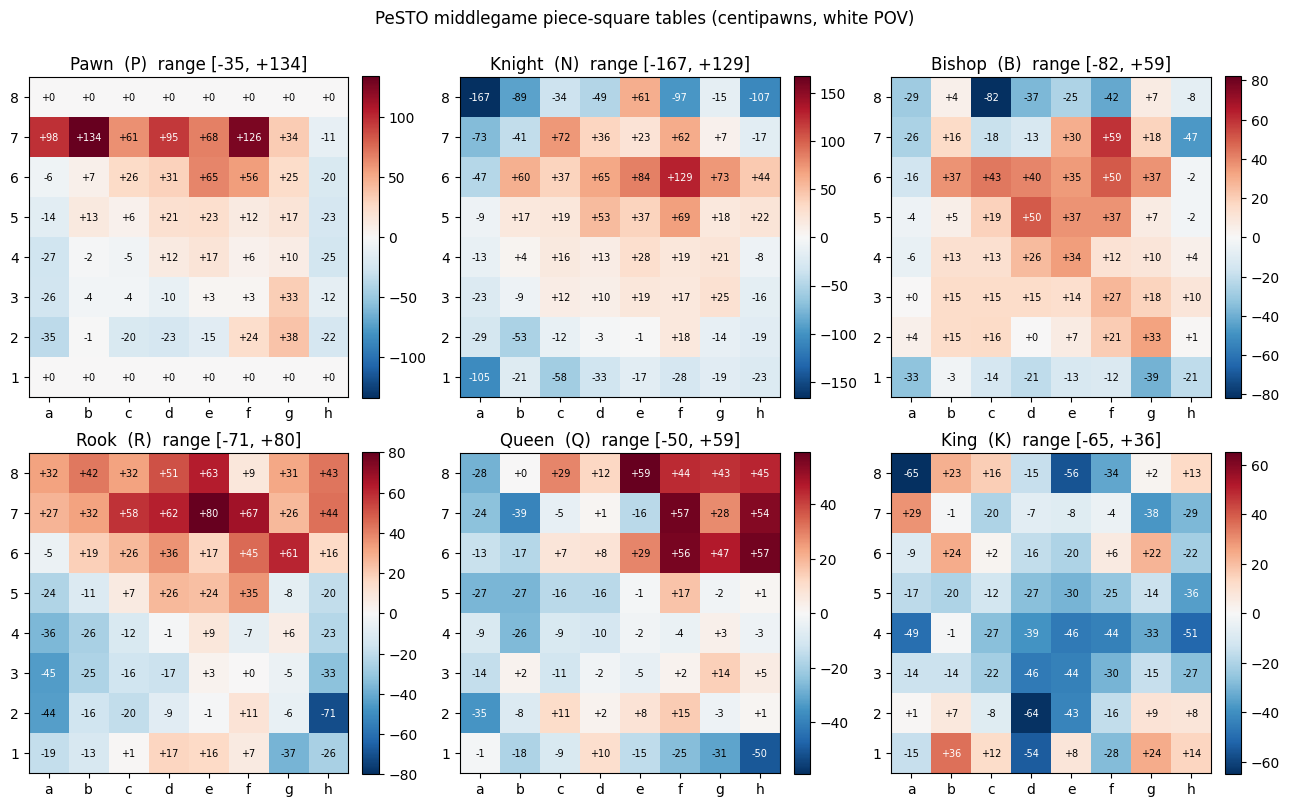

In [4]:
letters = ['P', 'N', 'B', 'R', 'Q', 'K']
names = ['Pawn', 'Knight', 'Bishop', 'Rook', 'Queen', 'King']
files_lbl = list('abcdefgh')
ranks_lbl = list('12345678')

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, letter, name, table in zip(axes.flat, letters, names, PSQT):
    vmax = np.abs(table).max()
    im = ax.imshow(np.flipud(table), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(8), files_lbl)
    ax.set_yticks(range(8), reversed(ranks_lbl))
    ax.set_title(f'{name}  ({letter})  range [{table.min():+d}, {table.max():+d}]')
    flipped = np.flipud(table)
    for r in range(8):
        for f in range(8):
            color = 'white' if abs(flipped[r, f]) > vmax * 0.55 else 'black'
            ax.text(f, r, f'{flipped[r, f]:+d}', ha='center', va='center',
                    color=color, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('PeSTO middlegame piece-square tables (centipawns, white POV)', y=1.0)
plt.tight_layout(); plt.show()

Quick read of the pictures:

- Pawn: rewards advanced pawns, penalises the central pawns on rank 2 (they block the bishops). Ranks 1 and 8 are zero because pawns can't be there.
- Knight: textbook centralisation. Corners are awful (-167 at a8), centre is rewarded.
- Bishop: mild centralisation plus a long-diagonal bias.
- Rook: the classic +30 bonus on the 7th rank.
- Queen: small numbers, queens don't need positional help.
- King: opposite of everything else. Safer in the corner during the middlegame, exposed in the centre. PeSTO has a separate endgame table where these flip.

## Material values

The first five entries of $\mathbf{w}$ are the material weights. PeSTO uses a slightly unusual scale where pawn = 82 cp instead of the conventional 100, but the ratios are the same.

In [5]:
w_mat = Evaluator.material_only().weights[MATERIAL_SLICE]
print('material weights from Evaluator.material_only():')
for letter, val in zip('PNBRQ', w_mat):
    print(f'   {letter}: {val:6.1f} cp')
print()
expected = [MATERIAL[chess.PAWN], MATERIAL[chess.KNIGHT], MATERIAL[chess.BISHOP],
            MATERIAL[chess.ROOK], MATERIAL[chess.QUEEN]]
print('expected (PeSTO MG):       ', expected)
assert np.allclose(w_mat, expected), 'material weights mismatch'

material weights from Evaluator.material_only():
   P:   82.0 cp
   N:  337.0 cp
   B:  365.0 cp
   R:  477.0 cp
   Q: 1025.0 cp

expected (PeSTO MG):        [82, 337, 365, 477, 1025]


$B \approx N$, $R \approx N + 2P$ (the exchange), $Q \approx 2R + P$. Centuries of chess wisdom packed into a 5-vector.

## phi on a few positions

Four sanity-check positions, each one stressing a different part of the layout.

In [6]:
evaluator = Evaluator.psqt_handcrafted()

def show_position(name, board, n_top=10):
    v = phi(board)
    nz = np.flatnonzero(v)
    score = evaluator.score(board)
    print(f'=== {name} ===')
    print(f'   nonzero entries : {len(nz)} / {N_FEATURES}')
    print(f'   psqt score      : {score:+.1f} cp (white POV)')
    top = nz[np.argsort(-np.abs(v[nz]))][:n_top]
    print(f'   top {len(top)} entries by |value|:')
    for i in top:
        print(f'     [{i:3d}] {FEATURE_NAMES[i]:<22s} = {v[i]:+.0f}')
    display(SVG(chess.svg.board(board, size=240)))
    print()

=== starting position ===
   nonzero entries : 1 / 391
   psqt score      : +10.0 cp (white POV)
   top 1 entries by |value|:
     [390] side_to_move           = +1


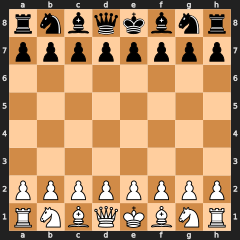

In [7]:
show_position('starting position', chess.Board())

=== after 1.e4 ===
   nonzero entries : 3 / 391
   psqt score      : +22.0 cp (white POV)
   top 3 entries by |value|:
     [ 17] psqt_P_e2              = -1
     [ 33] psqt_P_e4              = +1
     [390] side_to_move           = -1


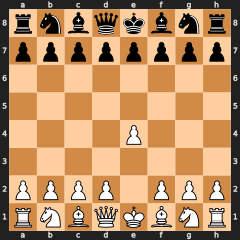

In [8]:
# 1.e4: only the e2 and e4 pawn squares change, plus the side-to-move bit
b = chess.Board(); b.push_san('e4')
show_position('after 1.e4', b)

=== white up a queen ===
   nonzero entries : 3 / 391
   psqt score      : +1045.0 cp (white POV)
   top 3 entries by |value|:
     [  4] material_Q             = +1
     [264] psqt_Q_d1              = +1
     [390] side_to_move           = +1


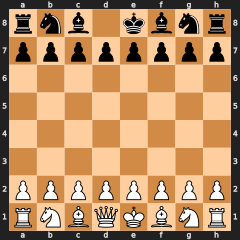

In [9]:
# white up a queen - exercises the material slice
b = chess.Board('rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1')
show_position('white up a queen', b)

=== middlegame (Karpov-Kasparov 1985) ===
   nonzero entries : 11 / 391
   psqt score      : +3.0 cp (white POV)
   top 11 entries by |value|:
     [ 14] psqt_P_b2              = +1
     [ 24] psqt_P_d3              = +1
     [ 25] psqt_P_e3              = -1
     [ 30] psqt_P_b4              = -1
     [ 31] psqt_P_c4              = -1
     [ 33] psqt_P_e4              = +1
     [ 87] psqt_N_c3              = +1
     [ 97] psqt_N_e4              = -1
     [142] psqt_B_b2              = -1
     [153] psqt_B_e3              = +1
     [390] side_to_move           = +1


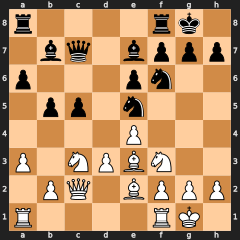

In [10]:
# Karpov-Kasparov, 1985 WCh game 16, around move 16
b = chess.Board('r4rk1/1bq1bppp/p3pn2/1pp1n3/4P3/P1NPBN2/1PQ1BPPP/R4RK1 w - - 0 16')
show_position('middlegame (Karpov-Kasparov 1985)', b, n_top=15)